In [90]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import xgboost as xgb

In [92]:
mnist = fetch_openml('mnist_784', version=1, as_frame=False)

X = mnist.data / 255.0  # Normalize pixel values
y = mnist.target.astype(int)  # Convert string labels to integers

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
) 

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.97      0.96      2071
           1       0.95      0.97      0.96      2363
           2       0.91      0.90      0.91      2097
           3       0.90      0.89      0.89      2142
           4       0.92      0.91      0.92      2047
           5       0.89      0.87      0.88      1894
           6       0.94      0.95      0.95      2063
           7       0.93      0.94      0.94      2188
           8       0.90      0.88      0.89      2048
           9       0.90      0.89      0.90      2087

    accuracy                           0.92     21000
   macro avg       0.92      0.92      0.92     21000
weighted avg       0.92      0.92      0.92     21000

Logistic Regression Accuracy: 0.919952380952381


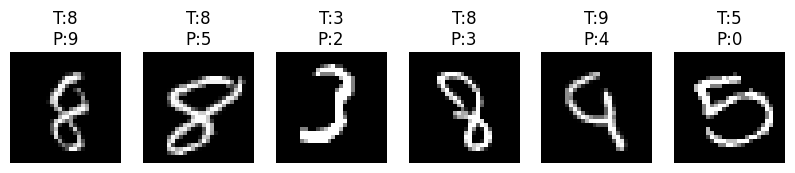

In [98]:
# Logistic Regression
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)
log_pred = log_model.predict(X_test)

print("Logistic Regression Classification Report:")
print(classification_report(y_test, log_pred))

log_acc = accuracy_score(y_test, log_pred)
print("Logistic Regression Accuracy:", log_acc)

wrong_log = np.where(log_pred != y_test)[0][:6]
plt.figure(figsize=(10, 2))
for i in range(6):
    plt.subplot(1, 6, i + 1)
    plt.imshow(X_test[wrong_log[i]].reshape(28, 28), cmap='gray')
    plt.title(f"T:{y_test[wrong_log[i]]}\nP:{log_pred[wrong_log[i]]}")
    plt.axis('off')
plt.show()

SVM Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      2071
           1       0.98      0.99      0.99      2363
           2       0.98      0.98      0.98      2097
           3       0.98      0.97      0.97      2142
           4       0.98      0.97      0.97      2047
           5       0.98      0.97      0.98      1894
           6       0.98      0.99      0.98      2063
           7       0.98      0.98      0.98      2188
           8       0.97      0.97      0.97      2048
           9       0.96      0.96      0.96      2087

    accuracy                           0.98     21000
   macro avg       0.98      0.98      0.98     21000
weighted avg       0.98      0.98      0.98     21000

SVM Accuracy: 0.9767619047619047


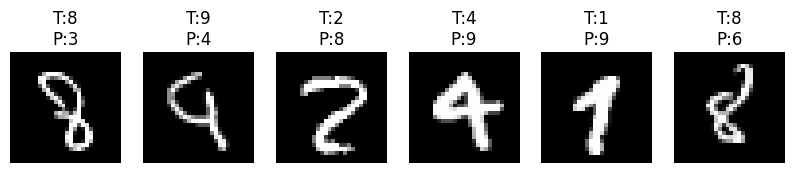

In [99]:
#Support Vector Machine (SVM)
svm_model = SVC()
svm_model.fit(X_train, y_train)
svm_pred = svm_model.predict(X_test)

print("SVM Classification Report:")
print(classification_report(y_test, svm_pred))

svm_acc = accuracy_score(y_test, svm_pred)
print("SVM Accuracy:", svm_acc)

wrong_svm = np.where(svm_pred != y_test)[0][:6]
plt.figure(figsize=(10, 2))
for i in range(6):
    plt.subplot(1, 6, i + 1)
    plt.imshow(X_test[wrong_svm[i]].reshape(28, 28), cmap='gray')
    plt.title(f"T:{y_test[wrong_svm[i]]}\nP:{svm_pred[wrong_svm[i]]}")
    plt.axis('off')
plt.show()

Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.93      0.92      2071
           1       0.94      0.96      0.95      2363
           2       0.84      0.84      0.84      2097
           3       0.81      0.82      0.82      2142
           4       0.87      0.86      0.87      2047
           5       0.82      0.80      0.81      1894
           6       0.90      0.90      0.90      2063
           7       0.89      0.90      0.89      2188
           8       0.82      0.81      0.82      2048
           9       0.83      0.83      0.83      2087

    accuracy                           0.87     21000
   macro avg       0.86      0.86      0.86     21000
weighted avg       0.87      0.87      0.87     21000

Decision Tree Accuracy: 0.8664285714285714


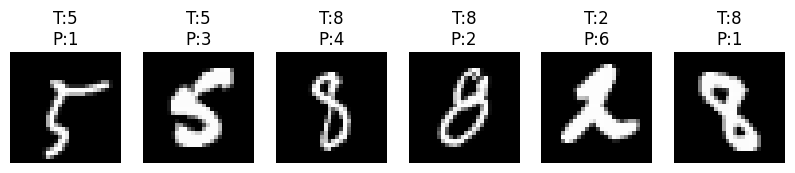

In [100]:
# Decision Tree
tree_model = DecisionTreeClassifier()
tree_model.fit(X_train, y_train)
tree_pred = tree_model.predict(X_test)

print("Decision Tree Classification Report:")
print(classification_report(y_test, tree_pred))

tree_acc = accuracy_score(y_test, tree_pred)
print("Decision Tree Accuracy:", tree_acc)

wrong_tree = np.where(tree_pred != y_test)[0][:6]
plt.figure(figsize=(10, 2))
for i in range(6):
    plt.subplot(1, 6, i + 1)
    plt.imshow(X_test[wrong_tree[i]].reshape(28, 28), cmap='gray')
    plt.title(f"T:{y_test[wrong_tree[i]]}\nP:{tree_pred[wrong_tree[i]]}")
    plt.axis('off')
plt.show()


Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      2071
           1       0.98      0.98      0.98      2363
           2       0.96      0.97      0.97      2097
           3       0.96      0.95      0.96      2142
           4       0.97      0.96      0.97      2047
           5       0.97      0.95      0.96      1894
           6       0.97      0.98      0.97      2063
           7       0.97      0.97      0.97      2188
           8       0.96      0.95      0.96      2048
           9       0.94      0.94      0.94      2087

    accuracy                           0.97     21000
   macro avg       0.97      0.97      0.97     21000
weighted avg       0.97      0.97      0.97     21000

Random Forest Accuracy: 0.9656666666666667


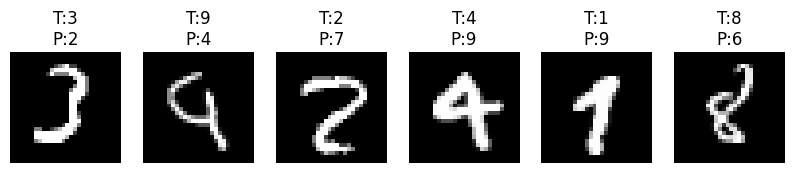

In [101]:
# Random Forest
rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

print("Random Forest Classification Report:")
print(classification_report(y_test, rf_pred))

rf_acc = accuracy_score(y_test, rf_pred)
print("Random Forest Accuracy:", rf_acc)

wrong_rf = np.where(rf_pred != y_test)[0][:6]
plt.figure(figsize=(10, 2))
for i in range(6):
    plt.subplot(1, 6, i + 1)
    plt.imshow(X_test[wrong_rf[i]].reshape(28, 28), cmap='gray')
    plt.title(f"T:{y_test[wrong_rf[i]]}\nP:{rf_pred[wrong_rf[i]]}")
    plt.axis('off')
plt.show() 

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.98      2071
           1       0.99      0.99      0.99      2363
           2       0.98      0.98      0.98      2097
           3       0.98      0.97      0.98      2142
           4       0.98      0.96      0.97      2047
           5       0.98      0.97      0.97      1894
           6       0.97      0.98      0.98      2063
           7       0.98      0.98      0.98      2188
           8       0.97      0.97      0.97      2048
           9       0.96      0.96      0.96      2087

    accuracy                           0.97     21000
   macro avg       0.97      0.97      0.97     21000
weighted avg       0.97      0.97      0.97     21000

XGBoost Accuracy: 0.9749047619047619


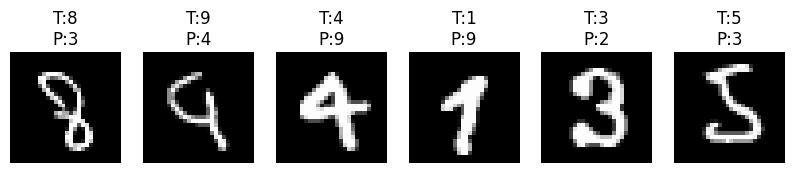

In [102]:
# XGBoost Classification
xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)

print("XGBoost Classification Report:")
print(classification_report(y_test, xgb_pred))

xgb_acc = accuracy_score(y_test, xgb_pred)
print("XGBoost Accuracy:", xgb_acc)

wrong_xgb = np.where(xgb_pred != y_test)[0][:6]
plt.figure(figsize=(10, 2))
for i in range(6):
    plt.subplot(1, 6, i + 1)
    plt.imshow(X_test[wrong_xgb[i]].reshape(28, 28), cmap='gray')
    plt.title(f"T:{y_test[wrong_xgb[i]]}\nP:{xgb_pred[wrong_xgb[i]]}")
    plt.axis('off')
plt.show()


,Model,Accuracy
1,SVM,0.976762
4,XGBoost,0.974905
3,Random Forest,0.965667
0,Logistic Regression,0.919952
2,Decision Tree,0.866429


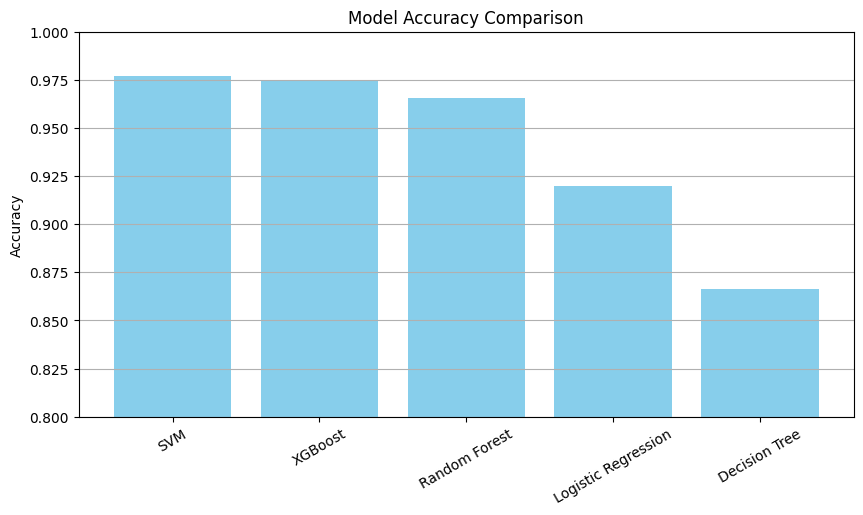

In [103]:
data = {
    'Model': ['Logistic Regression', 'SVM', 'Decision Tree', 'Random Forest', 'XGBoost'],
    'Accuracy': [log_acc, svm_acc, tree_acc, rf_acc, xgb_acc]
}

summary_df = pd.DataFrame(data)
summary_df = summary_df.sort_values("Accuracy", ascending=False)
display(summary_df)

plt.figure(figsize=(10, 5))
plt.bar(summary_df['Model'], summary_df['Accuracy'], color='skyblue')
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.xticks(rotation=30)
plt.ylim(0.8, 1.0)
plt.grid(axis='y')
plt.show()